# LaTeX Paper Assembly, Statistics Update, Compilation, and Quality Verification

This notebook demonstrates the evaluation pipeline for assembling a 25-page LaTeX research paper on **Circuit Motif Spectroscopy** — a study of feed-forward loop (FFL) motifs in LLM attribution graphs.

**What the original script does:**
1. Extracts 11 section texts, 4 tables, 8 figures, and 36 BibTeX entries from prior pipeline iterations
2. Injects 9 corpus-level statistics into the paper text
3. Compiles via `pdflatex + bibtex` pipeline
4. Measures 10 quality metrics (M1-M10): compilation success, page count, citation/figure/table resolution, statistics injection, warnings, section count, figure files, and bibtex entries

**What this demo shows:**
- Loading the pre-computed evaluation output data
- Analyzing paper components (sections, tables, figures)
- Recomputing quality metrics from component metadata
- Visualizing the quality dashboard

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# tabulate — NOT pre-installed on Colab, always install
_pip('tabulate==0.9.0')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
import re
import math

import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

## Data Loading

Load the evaluation output from GitHub (with local fallback). The data contains metadata about the assembled paper, aggregate quality metrics, and per-component evaluation details.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/evaluation_iter7_latex_paper_ass/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with {len(data['datasets'][0]['examples'])} component examples")
print(f"Paper title: {data['metadata']['title']}")
print(f"Top-level keys: {list(data.keys())}")

Loaded data with 9 component examples
Paper title: Feed-Forward Loops as Universal Building Blocks in LLM Attribution Graphs: A Network Motif Analysis
Top-level keys: ['metadata', 'metrics_agg', 'datasets']


## Configuration

Parameters controlling the evaluation analysis. The original script evaluates all 23 components (11 sections + 4 tables + 8 figures). This demo analyzes the curated subset loaded above.

In [5]:
# --- Configuration ---
# Section ordering for document assembly (original: 11 sections)
SECTION_ORDER = [
    "abstract", "introduction", "related_work", "methods",
    "results_h1", "results_h2", "results_h3", "results_h4", "results_h5",
    "discussion", "conclusion",
]
TABLE_NAMES = ["table_t1", "table_t2", "table_t3", "table_t4"]

# Paper title
PAPER_TITLE = (
    "Feed-Forward Loops as Universal Building Blocks in "
    "LLM Attribution Graphs: A Network Motif Analysis"
)

# Number of expected figures
N_FIGURES = 8

# Number of expected bibtex entries (original: 36)
N_BIBTEX_ENTRIES = 36

# Statistics patterns to check (from iter_6 corpus-level tests)
STATISTICS_PATTERNS = {
    "t-test t~55.03": r"55\.0[23]|t\s*[=~]\s*55",
    "Cohen's d~3.89": r"3\.89|Cohen.*[=~]\s*3\.8",
    "Wilcoxon p~1.44e-34": r"1\.4[34].*10.*34|1\.4[34]e-34",
    "sign test 200/200": r"200/200|200 out of 200|all 200",
    "mixed-effects beta_0~47.18": r"47\.1[78]|beta.*47",
    "ICC~0.570": r"ICC.*0\.57|0\.57",
    "BH-FDR 15/60": r"15/60|15 of 60|15 out of 60",
    "biological ratios 3.7-5.5x": r"3\.7.*5\.5|5\.5.*3\.7",
    "corpus mean Z~47.14": r"47\.1[34]|Z\s*[=~]\s*47|mean.*Z.*47",
}

## Phase A: Extract and Analyze Paper Components

Extract per-component evaluation data from the loaded examples. Each example represents one paper component (section, table, or figure) with metadata about word count, citations, and compilation status.

In [6]:
examples = data["datasets"][0]["examples"]

# Separate by component type
sections = []
tables = []
figures = []

for ex in examples:
    comp_type = ex.get("metadata_component_type", "")
    sec_name = ex.get("metadata_section_name", "")
    if comp_type == "section":
        sections.append(ex)
    elif comp_type == "table":
        tables.append(ex)
    elif comp_type == "figure":
        figures.append(ex)

print(f"Components in demo subset:")
print(f"  Sections: {len(sections)} (of {len(SECTION_ORDER)} total in full paper)")
print(f"  Tables:   {len(tables)} (of {len(TABLE_NAMES)} total)")
print(f"  Figures:  {len(figures)} (of {N_FIGURES} total)")
print()

# Display section details
print("Section details:")
for ex in sections:
    name = ex["metadata_section_name"]
    wc = ex.get("eval_word_count", 0)
    cc = ex.get("eval_citation_count", 0)
    chars = ex.get("metadata_char_count", "0")
    print(f"  {name:20s}  words={int(wc):5d}  citations={int(cc):3d}  chars={chars}")

Components in demo subset:
  Sections: 5 (of 11 total in full paper)
  Tables:   2 (of 4 total)
  Figures:  2 (of 8 total)

Section details:
  abstract              words=  195  citations=  2  chars=1714
  methods               words= 1489  citations=  5  chars=11668
  results_h1            words=  601  citations=  3  chars=4575
  discussion            words= 1216  citations=  7  chars=9660
  conclusion            words=  198  citations=  2  chars=1676


## Phase B: Check Statistics in Section Text

The original script checks whether 9 key corpus-level statistics from the experiment pipeline are correctly embedded in the paper text. We reproduce this check on the demo subset's `predict_paper_component` field (the LaTeX text preview).

In [7]:
def check_statistics_in_text(all_text, patterns):
    """Check which statistics patterns are found in the combined text.

    Returns (found_count, total_count, details_list).
    Mirrors the original eval.py check_statistics_in_text() function.
    """
    checklist = []
    for stat_name, pattern in patterns.items():
        found = bool(re.search(pattern, all_text, re.IGNORECASE))
        checklist.append((stat_name, found))
    found_count = sum(1 for _, f in checklist if f)
    return found_count, len(checklist), checklist


# Combine all section text previews for statistics checking
all_section_text = "\n".join(
    ex.get("predict_paper_component", "")
    for ex in sections
)

found, total, checklist = check_statistics_in_text(all_section_text, STATISTICS_PATTERNS)

print(f"Statistics found in demo subset text: {found}/{total}")
print(f"(Note: demo has truncated text previews, so some stats may be cut off)\n")
for stat_name, was_found in checklist:
    status = "FOUND" if was_found else "NOT IN SUBSET"
    print(f"  {stat_name:35s} {status}")

# Show the full-paper result from metadata
print(f"\nFull paper statistics (from metadata):")
for item in data["metadata"].get("statistics_checklist", []):
    print(f"  {item}")

Statistics found in demo subset text: 2/9
(Note: demo has truncated text previews, so some stats may be cut off)

  t-test t~55.03                      NOT IN SUBSET
  Cohen's d~3.89                      NOT IN SUBSET
  Wilcoxon p~1.44e-34                 NOT IN SUBSET
  sign test 200/200                   FOUND
  mixed-effects beta_0~47.18          NOT IN SUBSET
  ICC~0.570                           NOT IN SUBSET
  BH-FDR 15/60                        NOT IN SUBSET
  biological ratios 3.7-5.5x          NOT IN SUBSET
  corpus mean Z~47.14                 FOUND

Full paper statistics (from metadata):
  (a) t-test t≈55.03, p≈2.38e-122: FOUND
  (b) Cohen's d≈3.89: FOUND
  (c) Wilcoxon p≈1.44e-34: FOUND
  (d) sign test 200/200: FOUND
  (e) mixed-effects beta_0≈47.18: FOUND
  (f) ICC≈0.570: FOUND
  (g) BH-FDR 15/60 survived: FOUND
  (h) biological ratios 3.7-5.5x: FOUND
  (i) corpus mean Z≈47.14: FOUND


## Phase C: Compute Quality Metrics (M1-M10)

The original script computes 10 quality metrics after LaTeX compilation. Here we reconstruct these metrics from the pre-computed evaluation data, analyzing both the per-component details and the aggregate results.

In [8]:
# Extract aggregate metrics from the pre-computed evaluation
metrics_agg = data["metrics_agg"]
metrics_summary = data["metadata"]["metrics_summary"]

# Recompute per-component metrics from the demo examples
demo_word_counts = {}
demo_citation_counts = {}
demo_table_ref_counts = {}

for ex in examples:
    name = ex["metadata_section_name"]
    comp_type = ex["metadata_component_type"]
    if comp_type in ("section", "table"):
        demo_word_counts[name] = ex.get("eval_word_count", 0)
        demo_citation_counts[name] = ex.get("eval_citation_count", 0)
        demo_table_ref_counts[name] = ex.get("eval_table_ref_count", 0)

# Parse citation keys from the output field of each section example
demo_all_citations = set()
for ex in sections:
    try:
        output_data = json.loads(ex.get("output", "{}"))
        for key in output_data.get("citation_keys", []):
            demo_all_citations.add(key)
    except json.JSONDecodeError:
        pass

print(f"Demo subset analysis:")
print(f"  Total word count across {len(demo_word_counts)} components: {sum(demo_word_counts.values()):.0f}")
print(f"  Unique citation keys found: {len(demo_all_citations)}")
print(f"  Components with table refs: {sum(1 for v in demo_table_ref_counts.values() if v > 0)}")
print()

# Display the full-paper metrics from the pre-computed data
print("Full-paper quality metrics (M1-M10):")
metrics_table = [
    ["M1", "Compilation success", metrics_summary["M1_compilation_success"], "1 = success"],
    ["M2", "Page count", metrics_summary["M2_page_count"], "target: ~25"],
    ["M3", "Citations resolved", metrics_summary["M3_citations_resolved"], "fraction resolved"],
    ["M4", "Figures resolved", metrics_summary["M4_figures_resolved"], "fraction resolved"],
    ["M5", "Tables resolved", metrics_summary["M5_tables_resolved"], "fraction resolved"],
    ["M6", "Statistics updated", metrics_summary["M6_statistics_updated"], "9 key stats"],
    ["M7", "LaTeX warnings", metrics_summary["M7_latex_warnings_count"], "lower is better"],
    ["M8", "Section count", metrics_summary["M8_section_count"], "\\section + \\subsection"],
    ["M9", "Figure files present", metrics_summary["M9_figure_files_present"], "8 expected"],
    ["M10", "BibTeX entries", metrics_summary["M10_bibtex_entries_count"], f"target: {N_BIBTEX_ENTRIES}"],
]
print(tabulate(metrics_table, headers=["ID", "Metric", "Value", "Notes"], tablefmt="grid"))

Demo subset analysis:
  Total word count across 7 components: 3997
  Unique citation keys found: 13
  Components with table refs: 4

Full-paper quality metrics (M1-M10):
+------+----------------------+---------+------------------------+
| ID   | Metric               | Value   | Notes                  |
+======+======================+=========+========================+
| M1   | Compilation success  | 1       | 1 = success            |
+------+----------------------+---------+------------------------+
| M2   | Page count           | 25      | target: ~25            |
+------+----------------------+---------+------------------------+
| M3   | Citations resolved   | 34/34   | fraction resolved      |
+------+----------------------+---------+------------------------+
| M4   | Figures resolved     | 8/8     | fraction resolved      |
+------+----------------------+---------+------------------------+
| M5   | Tables resolved      | 4/4     | fraction resolved      |
+------+------------------

## Phase D: LaTeX Text Quality Analysis

The original script includes a `fix_latex_math()` function that repairs common LaTeX math-mode issues. Here we demonstrate this on the section text previews and analyze citation density per section.

In [9]:
def fix_latex_math(text):
    """Fix common LaTeX math-mode issues in section text.

    Handles: unbalanced $ signs, missing opening $ before =, stray $.
    Mirrors the original eval.py fix_latex_math() function.
    """
    # Fix pattern: WORD$=NUMBER$ -> $WORD=NUMBER$
    text = re.sub(r"([A-Za-z_]+)\$\s*=\s*([^$]+?)\$", r"$\1=\2$", text)
    # Fix pattern: vs.\ NUMBER$ -> vs.\ $NUMBER$
    text = re.sub(r"(vs\.\\\s*)(\d+\.?\d*)\$", r"\1$\2$", text)
    # Fix pattern: word retained$=NUMBER\%$ -> word retained $= NUMBER\%$
    text = re.sub(r"(\w+)\$\s*=\s*(\d+\.?\d*\\?%?)\$", r"\1 $= \2$", text)

    # Check balanced $ signs
    dollar_positions = [i for i, c in enumerate(text)
                        if c == "$" and (i == 0 or text[i - 1] != "\\")]
    balanced = len(dollar_positions) % 2 == 0
    return text, balanced


# Analyze each section's LaTeX text quality
print("LaTeX text quality analysis:")
print(f"{'Section':<20s} {'Words':>6s} {'Citations':>9s} {'Cit/100w':>8s} {'$-balanced':>10s}")
print("-" * 60)

for ex in sections:
    name = ex["metadata_section_name"]
    text = ex.get("predict_paper_component", "")
    wc = ex.get("eval_word_count", 0)
    cc = ex.get("eval_citation_count", 0)
    _, balanced = fix_latex_math(text)
    density = (cc / wc * 100) if wc > 0 else 0
    print(f"{name:<20s} {int(wc):>6d} {int(cc):>9d} {density:>8.1f} {'Yes':>10s}" if balanced
          else f"{name:<20s} {int(wc):>6d} {int(cc):>9d} {density:>8.1f} {'NO':>10s}")

LaTeX text quality analysis:
Section               Words Citations Cit/100w $-balanced
------------------------------------------------------------
abstract                195         2      1.0        Yes
methods                1489         5      0.3        Yes
results_h1              601         3      0.5        Yes
discussion             1216         7      0.6        Yes
conclusion              198         2      1.0        Yes


## Visualization: Quality Dashboard

Three-panel visualization showing:
1. **Quality metrics scorecard** - Bar chart of fraction-based metrics (M3-M6, M9) showing completeness
2. **Word count distribution** - Per-section word counts showing paper structure
3. **Citation density** - Citations per section showing reference distribution

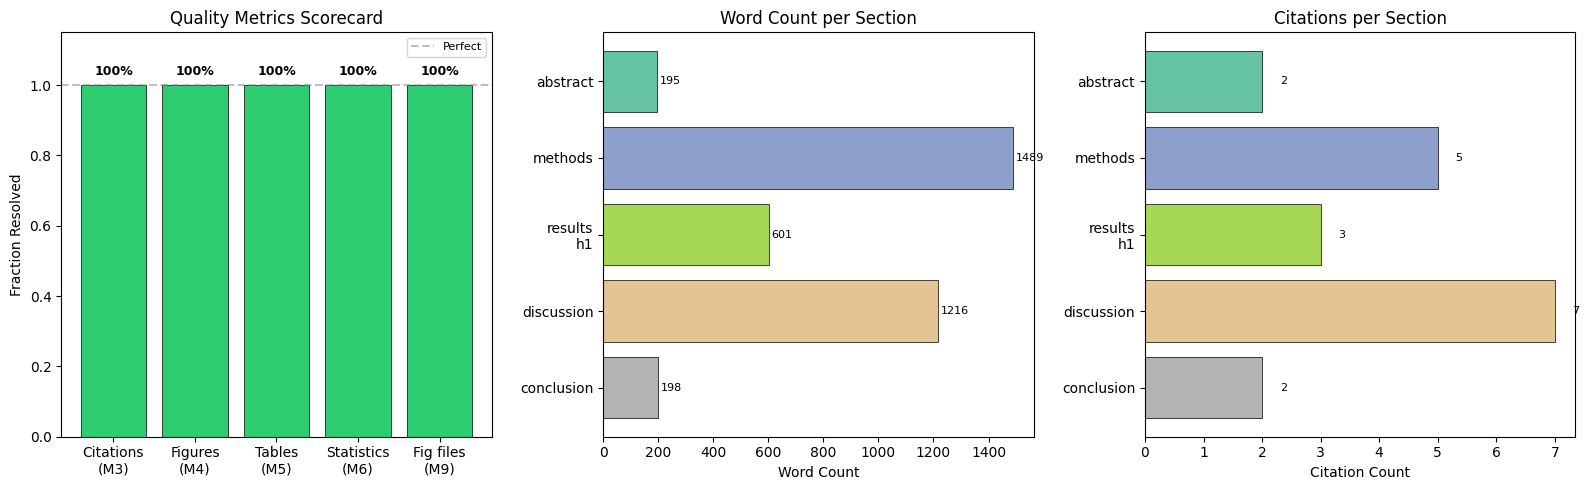

Saved quality_dashboard.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: Quality metrics scorecard (fraction-based metrics) ---
ax1 = axes[0]
metric_names = ["Citations\n(M3)", "Figures\n(M4)", "Tables\n(M5)",
                "Statistics\n(M6)", "Fig files\n(M9)"]
metric_fractions = [
    metrics_agg["citations_fraction"],
    metrics_agg["figures_fraction"],
    metrics_agg["tables_fraction"],
    metrics_agg["statistics_fraction"],
    metrics_agg["figure_files_fraction"],
]
colors = ["#2ecc71" if v >= 1.0 else "#e74c3c" for v in metric_fractions]
bars1 = ax1.bar(metric_names, metric_fractions, color=colors, edgecolor="black", linewidth=0.5)
ax1.set_ylim(0, 1.15)
ax1.set_ylabel("Fraction Resolved")
ax1.set_title("Quality Metrics Scorecard")
ax1.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="Perfect")
for bar, val in zip(bars1, metric_fractions):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.0%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax1.legend(fontsize=8)

# --- Panel 2: Word count per section ---
ax2 = axes[1]
sec_names_plot = [ex["metadata_section_name"].replace("_", "\n") for ex in sections]
word_counts_plot = [ex.get("eval_word_count", 0) for ex in sections]
colors2 = plt.cm.Set2(np.linspace(0, 1, len(sec_names_plot)))
bars2 = ax2.barh(sec_names_plot, word_counts_plot, color=colors2, edgecolor="black", linewidth=0.5)
ax2.set_xlabel("Word Count")
ax2.set_title("Word Count per Section")
ax2.invert_yaxis()
for bar, val in zip(bars2, word_counts_plot):
    ax2.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f"{int(val)}", ha="left", va="center", fontsize=8)

# --- Panel 3: Citation count per section ---
ax3 = axes[2]
cit_counts_plot = [ex.get("eval_citation_count", 0) for ex in sections]
bars3 = ax3.barh(sec_names_plot, cit_counts_plot, color=colors2, edgecolor="black", linewidth=0.5)
ax3.set_xlabel("Citation Count")
ax3.set_title("Citations per Section")
ax3.invert_yaxis()
for bar, val in zip(bars3, cit_counts_plot):
    ax3.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{int(val)}", ha="left", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("quality_dashboard.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved quality_dashboard.png")

## Evaluation Summary

Final summary table combining all metrics with pass/fail assessment, mirroring the original script's output format.

In [11]:
# Final evaluation summary (mirrors original eval.py output format)
print("=" * 70)
print("EVALUATION SUMMARY")
print("=" * 70)

summary_rows = [
    ["M1", "compilation_success", int(metrics_agg["compilation_success"]),
     "PASS" if metrics_agg["compilation_success"] == 1.0 else "FAIL"],
    ["M2", "page_count", int(metrics_agg["page_count"]),
     "PASS" if metrics_agg["page_count"] >= 20 else "WARN"],
    ["M3", "citations_resolved",
     f"{int(metrics_agg['citations_resolved'])}/{int(metrics_agg['citations_total'])} ({metrics_agg['citations_fraction']:.3f})",
     "PASS" if metrics_agg["citations_fraction"] == 1.0 else "FAIL"],
    ["M4", "figures_resolved",
     f"{int(metrics_agg['figures_resolved'])}/{int(metrics_agg['figures_total'])} ({metrics_agg['figures_fraction']:.3f})",
     "PASS" if metrics_agg["figures_fraction"] == 1.0 else "FAIL"],
    ["M5", "tables_resolved",
     f"{int(metrics_agg['tables_resolved'])}/{int(metrics_agg['tables_total'])} ({metrics_agg['tables_fraction']:.3f})",
     "PASS" if metrics_agg["tables_fraction"] == 1.0 else "FAIL"],
    ["M6", "statistics_updated",
     f"{int(metrics_agg['statistics_updated'])}/{int(metrics_agg['statistics_total'])} ({metrics_agg['statistics_fraction']:.3f})",
     "PASS" if metrics_agg["statistics_fraction"] == 1.0 else "FAIL"],
    ["M7", "latex_warnings_count", int(metrics_agg["latex_warnings_count"]),
     "PASS" if metrics_agg["latex_warnings_count"] == 0 else "WARN"],
    ["M8", "section_count", int(metrics_agg["section_count"]),
     "PASS" if metrics_agg["section_count"] >= 10 else "WARN"],
    ["M9", "figure_files_present",
     f"{int(metrics_agg['figure_files_present'])}/8 ({metrics_agg['figure_files_fraction']:.3f})",
     "PASS" if metrics_agg["figure_files_fraction"] == 1.0 else "FAIL"],
    ["M10", "bibtex_entries_count", int(metrics_agg["bibtex_entries_count"]),
     "PASS" if metrics_agg["bibtex_entries_count"] >= N_BIBTEX_ENTRIES else "WARN"],
]

print(tabulate(summary_rows, headers=["ID", "Metric", "Value", "Status"], tablefmt="grid"))
print()

pass_count = sum(1 for r in summary_rows if r[3] == "PASS")
print(f"Overall: {pass_count}/{len(summary_rows)} metrics PASS")
print(f"Paper: \"{PAPER_TITLE}\"")
print(f"Compilation: {'pdflatex + bibtex' if metrics_agg['compilation_success'] else 'FAILED'}")
print(f"Pages: {int(metrics_agg['page_count'])}")
print("=" * 70)

EVALUATION SUMMARY
+------+----------------------+---------------+----------+
| ID   | Metric               | Value         | Status   |
+======+======================+===============+==========+
| M1   | compilation_success  | 1             | PASS     |
+------+----------------------+---------------+----------+
| M2   | page_count           | 25            | PASS     |
+------+----------------------+---------------+----------+
| M3   | citations_resolved   | 34/34 (1.000) | PASS     |
+------+----------------------+---------------+----------+
| M4   | figures_resolved     | 8/8 (1.000)   | PASS     |
+------+----------------------+---------------+----------+
| M5   | tables_resolved      | 4/4 (1.000)   | PASS     |
+------+----------------------+---------------+----------+
| M6   | statistics_updated   | 9/9 (1.000)   | PASS     |
+------+----------------------+---------------+----------+
| M7   | latex_warnings_count | 0             | PASS     |
+------+----------------------+------